# Głębokie Uczenie w Praktyce
## Laboratorium 2
### Mateusz Horczak

#### Ćwiczenie 1. Wczytanie zbioru danych IMDB

In [37]:
from tensorflow.keras.datasets import imdb
import numpy as np
import matplotlib.pyplot as plt
import string


from tensorflow.keras import models
from tensorflow.keras import layers
from deep_translator import GoogleTranslator

In [15]:
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)

In [16]:
print("Train examples:", len(train_data))
print("Test examples: ", len(test_data))

print("Train positive:", sum(train_labels))
print("Train negative: ", len(train_labels) - sum(train_labels))

print("Test positive: ", sum(test_labels))
print("Test negative:  ", len(test_labels) - sum(test_labels))

Train examples: 25000
Test examples:  25000
Train positive: 12500
Train negative:  12500
Test positive:  12500
Test negative:   12500


In [17]:
word_index = imdb.get_word_index()
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])
decoded_review = ' '.join([reverse_word_index.get(i - 3, '?') for i in train_data[0]])

In [18]:
decoded_review

"? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you th

#### Ćwiczenie 2. Przygotowywanie danych

In [19]:
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.
    return results

x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

In [20]:
print('x_train[0]:', x_train[0])
print('len(x_train[0]):', len(x_train[0]))
print('y_train[0]:', y_train[0])

print('\nx_test[0]:', x_test[0])
print('len(x_test[0]):', len(x_test[0]))
print('y_test[0]:', y_test[0])

x_train[0]: [0. 1. 1. ... 0. 0. 0.]
len(x_train[0]): 10000
y_train[0]: 1.0

x_test[0]: [0. 1. 1. ... 0. 0. 0.]
len(x_test[0]): 10000
y_test[0]: 0.0


#### Ćwiczenie 3. Budowa sieci neuronowej

In [21]:
model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))
model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

#### Ćwiczenie 4. Walidacja modelu

In [22]:
x_val = x_train[:10000]
partial_x_train = x_train[10000:]
y_val = y_train[:10000]
partial_y_train = y_train[10000:]
history = model.fit(partial_x_train, partial_y_train, epochs=20, batch_size=512, validation_data=(x_val, y_val))
history_dict = history.history
print('history_dict keys: ', history_dict.keys())

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.7580 - loss: 0.5639 - val_accuracy: 0.8517 - val_loss: 0.4458
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8860 - loss: 0.3671 - val_accuracy: 0.8795 - val_loss: 0.3406
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9099 - loss: 0.2768 - val_accuracy: 0.8879 - val_loss: 0.2967
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9252 - loss: 0.2252 - val_accuracy: 0.8878 - val_loss: 0.2804
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9377 - loss: 0.1909 - val_accuracy: 0.8899 - val_loss: 0.2741
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9455 - loss: 0.1643 - val_accuracy: 0.8871 - val_loss: 0.2770
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9537 - loss: 0.1435 - val_accuracy: 0.8872 - val_loss: 0.2798
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9607 - loss: 0.1261 - val_accuracy: 0.8860 - v

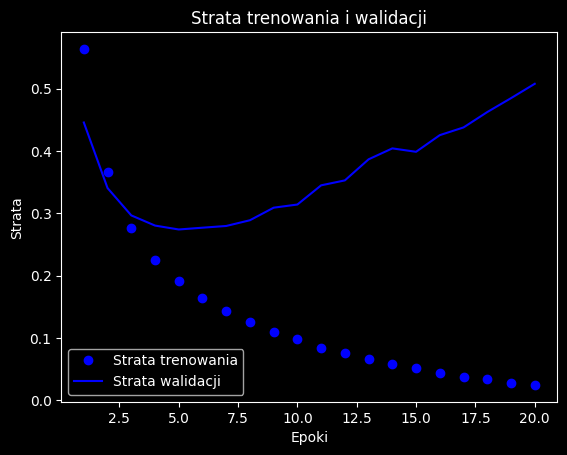

In [23]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.plot(epochs, loss, 'bo', label='Strata trenowania')
plt.plot(epochs, val_loss, 'b', label='Strata walidacji')
plt.title('Strata trenowania i walidacji')
plt.xlabel('Epoki')
plt.ylabel('Strata')
plt.legend()

plt.show()

#### Ćwiczenie 6. Wykres zmian dokładności trenowania i walidacji

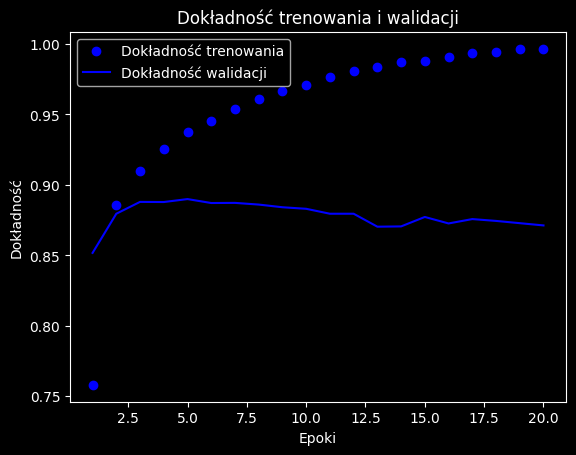

In [24]:
acc_values = history_dict['accuracy']
val_acc_values = history_dict['val_accuracy']

plt.plot(epochs, acc, 'bo', label='Dokładność trenowania')
plt.plot(epochs, val_acc, 'b', label='Dokładność walidacji')
plt.title('Dokładność trenowania i walidacji')
plt.xlabel('Epoki')
plt.ylabel('Dokładność')

plt.legend()
plt.show()

##### Odp: Po 3 epoce następuje przeuczenie modelu

#### Ćwiczenie 7. Predykcja nowych danych

In [25]:
model.fit(x_train, y_train, epochs=4, batch_size=512)
results = model.evaluate(x_test, y_test)

print('results: ', results)
print('model.predict: ', model.predict(x_test))

Epoch 1/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9471 - loss: 0.2008
Epoch 2/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9586 - loss: 0.1360
Epoch 3/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9651 - loss: 0.1122
Epoch 4/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9712 - loss: 0.0962
782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8641 - loss: 0.4156
results:  [0.4156455397605896, 0.8641200065612793]
782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
model.predict:  [[0.02454326]
 [0.99976534]
 [0.26626915]
 ...
 [0.06056933]
 [0.02826216]
 [0.9414181 ]]


#### Ćwiczenie 8. Użyj wytrenowanego modelu do klasyfikacji recenzji wprowadzonej przez użytkownika

In [38]:
def encode_review(review):
    sequence = []
    for word in review.lower().split():
        index = word_index.get(word)
        if index is not None:
            index += 3 # offset
        else:
            index = 2 # set as unknown word
        if index >= 10000:
            index = 2 # set as unknown word
        sequence.append(index)
    return sequence

def clean_review(text):
    translator = str.maketrans('', '', string.punctuation)
    text = text.translate(translator)
    text = ' '.join(text.split())
    return text

review_pl = input("Wpisz krótką recenzję filmu po polsku: ")

print("Tłumaczę na angielski...")
review_en = GoogleTranslator(source='pl', target='en').translate(review_pl)
print(f"Tłumaczenie: \"{review_en}\"")
review_en = clean_review(review_en)
print(f"Tłumaczenie po usunięciu interpunkcji: \"{review_en}\"")

encoded_review = encode_review(review_en)
user_vector = vectorize_sequences([encoded_review])
prediction = model.predict(user_vector, verbose=0)

score = prediction[0][0]

print(f"\nPrawdopodobieństwo pozytywne: {score:.4f}")
result = "pozytywną." if score > 0.5 else "negatywną."
print("Wystawiono recenzję ", result)

Tłumaczę na angielski...
Tłumaczenie: "Very good movie"
Tłumaczenie po usunięciu interpunkcji: "Very good movie"

Prawdopodobieństwo pozytywne: 0.6508
Wystawiono recenzję  pozytywną.
